# Phase 4: Machine Learning (Spark MLlib)
**Thực hiện bởi**: Tuấn (Group 3)

## Mục tiêu
1. **4.1** Đọc dữ liệu từ Hive `credit_transaction_db.cleaned_transactions`.
2. **4.2** `VectorAssembler` gom feature: `TX_AMOUNT`, `TX_TIME_SECONDS`, `tx_hour`, `is_weekend`, `is_night`, `customer_tx_count`, `customer_avg_amount`, `terminal_tx_count`.
3. **4.3** Class Weighting cho nhãn `TX_FRAUD` (dữ liệu lệch).
4. **4.4** Huấn luyện `LogisticRegression` (`pyspark.ml.classification`).
5. **4.5** Đánh giá bằng **Area Under PR-Curve** và **ROC-AUC** (`BinaryClassificationEvaluator`).

> **Lưu ý**: Không dùng Accuracy làm metric chính vì gian lận chiếm tỷ lệ rất nhỏ.
>
> Pipeline logic nằm trong `src/ml_module.py` (StandardScaler đặt trong pipeline ML, không sửa ETL Phase 2).

## 1. Import thư viện & module ML

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from pyspark.sql import functions as F

from src.ml_module import (
    FEATURE_COLS,
    LABEL_COL,
    WEIGHT_COL,
    HIVE_TABLE,
    get_ml_spark_session,
    load_ml_dataset,
    summarize_class_balance,
    prepare_feature_frame,
    add_class_weights,
    build_ml_pipeline,
    train_and_evaluate,
    evaluate_predictions,
)

print("Feature columns:", FEATURE_COLS)
print("Label column:", LABEL_COL)
print("Hive table:", HIVE_TABLE)

Feature columns: ['TX_AMOUNT', 'TX_TIME_SECONDS', 'tx_hour', 'is_weekend', 'is_night', 'customer_tx_count', 'customer_avg_amount', 'terminal_tx_count']
Label column: TX_FRAUD
Hive table: credit_transaction_db.cleaned_transactions


## 2. Khởi tạo Spark Session (Hive Metastore / local fallback)

In [3]:
spark = get_ml_spark_session(app_name="Phase4_Machine_Learning_Tuan")
spark.sparkContext.setLogLevel("WARN")
spark

[ML] Spark session ready (Hive URI: thrift://hive-metastore:9083).


## 3. [4.1] Truy xuất dữ liệu (dataset chuẩn của project)

**Dataset chuẩn**: `simulated-data-raw-csv/` (24 tháng, có cả `TX_FRAUD = 0` và `1`).

Theo đề bài Phase 4.1, notebook đọc từ Hive bảng đã ETL:
`credit_transaction_db.cleaned_transactions`
(= bản đã làm sạch / feature engineering từ `simulated-data-raw-csv`).

Thứ tự load:
1. **Hive** (sau khi chạy ETL full) — khuyến nghị
2. Fallback CSV: **`simulated-data-raw-csv`** (không dùng `data/mock` để train)

> `data/mock` chỉ là sample test ETL của team, không phải dataset train.

In [4]:
# 4.1: ưu tiên Hive (ETL từ simulated-data-raw-csv).
# Nếu chưa có Hive → tự fallback sang folder simulated-data-raw-csv (dataset chuẩn).
df_tx, source = load_ml_dataset(spark)

print(f"Dataset source: {source}")
print(f"Total rows: {df_tx.count():,}")
df_tx.printSchema()

print("\n=== Class balance (TX_FRAUD) ===")
class_balance = summarize_class_balance(df_tx)
class_balance.show(truncate=False)

fraud_rows = [r for r in class_balance.collect() if float(r[LABEL_COL]) == 1.0]
if not fraud_rows:
    raise ValueError(
        "Không thấy TX_FRAUD=1. Đang không dùng đúng dataset chuẩn. "
        "Hãy ETL từ simulated-data-raw-csv rồi chạy lại cell này."
    )
print(f"OK — có {int(fraud_rows[0]['count']):,} giao dịch gian lận trong dataset.")

[ML] Loaded 14,158,985 rows from Hive table `credit_transaction_db.cleaned_transactions`.
Dataset source: hive
Total rows: 14,158,985
root
 |-- TRANSACTION_ID: long (nullable = true)
 |-- TX_DATETIME: timestamp (nullable = true)
 |-- CUSTOMER_ID: long (nullable = true)
 |-- TERMINAL_ID: long (nullable = true)
 |-- TX_AMOUNT: double (nullable = true)
 |-- TX_TIME_SECONDS: long (nullable = true)
 |-- TX_TIME_DAYS: integer (nullable = true)
 |-- TX_FRAUD: integer (nullable = true)
 |-- TX_FRAUD_SCENARIO: integer (nullable = true)
 |-- tx_date: date (nullable = true)
 |-- tx_hour: integer (nullable = true)
 |-- tx_day_of_week: string (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_night: integer (nullable = true)
 |-- customer_tx_count: long (nullable = true)
 |-- customer_avg_amount: double (nullable = true)
 |-- terminal_tx_count: long (nullable = true)
 |-- tx_year_month: string (nullable = true)


=== Class balance (TX_FRAUD) ===
+--------+--------+--------+
|TX_FR

## 4. [4.2] Feature Engineering — VectorAssembler
- Chỉ giữ các cột feature được phân công.
- **Loại bỏ** định danh: `TRANSACTION_ID`, `CUSTOMER_ID`, `TERMINAL_ID`.
- **Không dùng** `TX_FRAUD_SCENARIO` (tránh label leakage).
- Pipeline: `VectorAssembler` → `StandardScaler` → `LogisticRegression`.

In [5]:
df_features = prepare_feature_frame(df_tx)
print("Prepared columns:", df_features.columns)
df_features.show(5, truncate=False)

pipeline = build_ml_pipeline()
for idx, stage in enumerate(pipeline.getStages()):
    print(f"Stage {idx}: {stage.__class__.__name__}")

Prepared columns: ['TX_AMOUNT', 'TX_TIME_SECONDS', 'tx_hour', 'is_weekend', 'is_night', 'customer_tx_count', 'customer_avg_amount', 'terminal_tx_count', 'TX_FRAUD']
+---------+---------------+-------+----------+--------+-----------------+-------------------+-----------------+--------+
|TX_AMOUNT|TX_TIME_SECONDS|tx_hour|is_weekend|is_night|customer_tx_count|customer_avg_amount|terminal_tx_count|TX_FRAUD|
+---------+---------------+-------+----------+--------+-----------------+-------------------+-----------------+--------+
|4.28     |2.9947797E7    |14.0   |0.0       |0.0     |102.0            |25.89892156862745  |2.0              |0.0     |
|92.87    |2.9481412E7    |5.0    |0.0       |1.0     |10.0             |53.05799999999999  |5.0              |0.0     |
|137.2    |2.9304815E7    |4.0    |0.0       |1.0     |108.0            |76.4250925925926   |2.0              |0.0     |
|62.46    |2.8966754E7    |6.0    |1.0       |0.0     |48.0             |68.57416666666667  |5.0             

## 5. [4.3] Class Weighting
Công thức balanced: `weight_c = n / (n_classes * n_c)`.

Class gian lận (thiểu số) nhận trọng số cao hơn → Logistic Regression không bỏ qua nhãn hiếm.

In [6]:
df_weighted = add_class_weights(df_features)

df_weighted.groupBy(LABEL_COL, WEIGHT_COL).count().orderBy(LABEL_COL).show(truncate=False)
df_weighted.select(*FEATURE_COLS[:3], LABEL_COL, WEIGHT_COL).show(8, truncate=False)

[ML] Class counts: {1.0: 35564, 0.0: 14123421}
[ML] Class weights: {1.0: 199.06344899336406, 0.0: 0.5012590434003207}
+--------+------------------+--------+
|TX_FRAUD|class_weight      |count   |
+--------+------------------+--------+
|0.0     |0.5012590434003207|14123421|
|1.0     |199.06344899336406|35564   |
+--------+------------------+--------+

+---------+---------------+-------+--------+------------------+
|TX_AMOUNT|TX_TIME_SECONDS|tx_hour|TX_FRAUD|class_weight      |
+---------+---------------+-------+--------+------------------+
|4.28     |2.9947797E7    |14.0   |0.0     |0.5012590434003207|
|92.87    |2.9481412E7    |5.0    |0.0     |0.5012590434003207|
|137.2    |2.9304815E7    |4.0    |0.0     |0.5012590434003207|
|62.46    |2.8966754E7    |6.0    |0.0     |0.5012590434003207|
|106.41   |3.0377027E7    |14.0   |0.0     |0.5012590434003207|
|162.53   |2.9232501E7    |8.0    |0.0     |0.5012590434003207|
|47.89    |3.0774569E7    |4.0    |0.0     |0.5012590434003207|
|105.76

## 6. [4.4] Train / Test split & huấn luyện Logistic Regression
- Split 80/20, `seed=42`.
- `LogisticRegression` dùng `weightCol=class_weight`.

In [7]:
model, metrics, train_df, predictions = train_and_evaluate(
    df_tx,
    train_ratio=0.8,
    seed=42,
)

print("Train class balance:")
train_df.groupBy(LABEL_COL).count().show()

print("Sample predictions (probability / prediction):")
predictions.select(
    LABEL_COL,
    "prediction",
    "probability",
).show(10, truncate=False)

[ML] Class counts: {1.0: 35564, 0.0: 14123421}
[ML] Class weights: {1.0: 199.06344899336406, 0.0: 0.5012590434003207}
[ML] Train rows=11,326,359 | Test rows=2,832,626
[ML] Evaluation on test set -> Area Under PR = 0.480006 | ROC-AUC = 0.811383
[ML] Note: Accuracy is intentionally not used (severe class imbalance).
Train class balance:
+--------+--------+
|TX_FRAUD|   count|
+--------+--------+
|     1.0|   28525|
|     0.0|11297834|
+--------+--------+

Sample predictions (probability / prediction):
+--------+----------+----------------------------------------+
|TX_FRAUD|prediction|probability                             |
+--------+----------+----------------------------------------+
|0.0     |0.0       |[0.680181113294555,0.319818886705445]   |
|0.0     |0.0       |[0.7289632949337062,0.27103670506629385]|
|0.0     |0.0       |[0.7397326831768867,0.2602673168231133] |
|0.0     |0.0       |[0.7354581184196638,0.2645418815803362] |
|0.0     |0.0       |[0.7384861701932971,0.26151382980

## 7. [4.5] Đánh giá — Area Under PR & ROC-AUC
Dùng `BinaryClassificationEvaluator`:
- `metricName="areaUnderPR"` (ưu tiên khi data lệch)
- `metricName="areaUnderROC"`

In [8]:
metrics_check = evaluate_predictions(predictions)

print("=" * 60)
print("PHASE 4 EVALUATION RESULTS (Test Set)")
print("=" * 60)
print(f"Area Under PR-Curve : {metrics_check['areaUnderPR']:.6f}")
print(f"ROC-AUC             : {metrics_check['areaUnderROC']:.6f}")
print("=" * 60)
print("Accuracy intentionally omitted (severe class imbalance).")

# Confusion-style counts (support slide/report; not used as primary metric)
predictions.groupBy(LABEL_COL, "prediction").count().orderBy(LABEL_COL, "prediction").show()

PHASE 4 EVALUATION RESULTS (Test Set)
Area Under PR-Curve : 0.480006
ROC-AUC             : 0.811387
Accuracy intentionally omitted (severe class imbalance).
+--------+----------+-------+
|TX_FRAUD|prediction|  count|
+--------+----------+-------+
|     0.0|       0.0|2489039|
|     0.0|       1.0| 336548|
|     1.0|       0.0|   2460|
|     1.0|       1.0|   4579|
+--------+----------+-------+



- Visualize Training Results

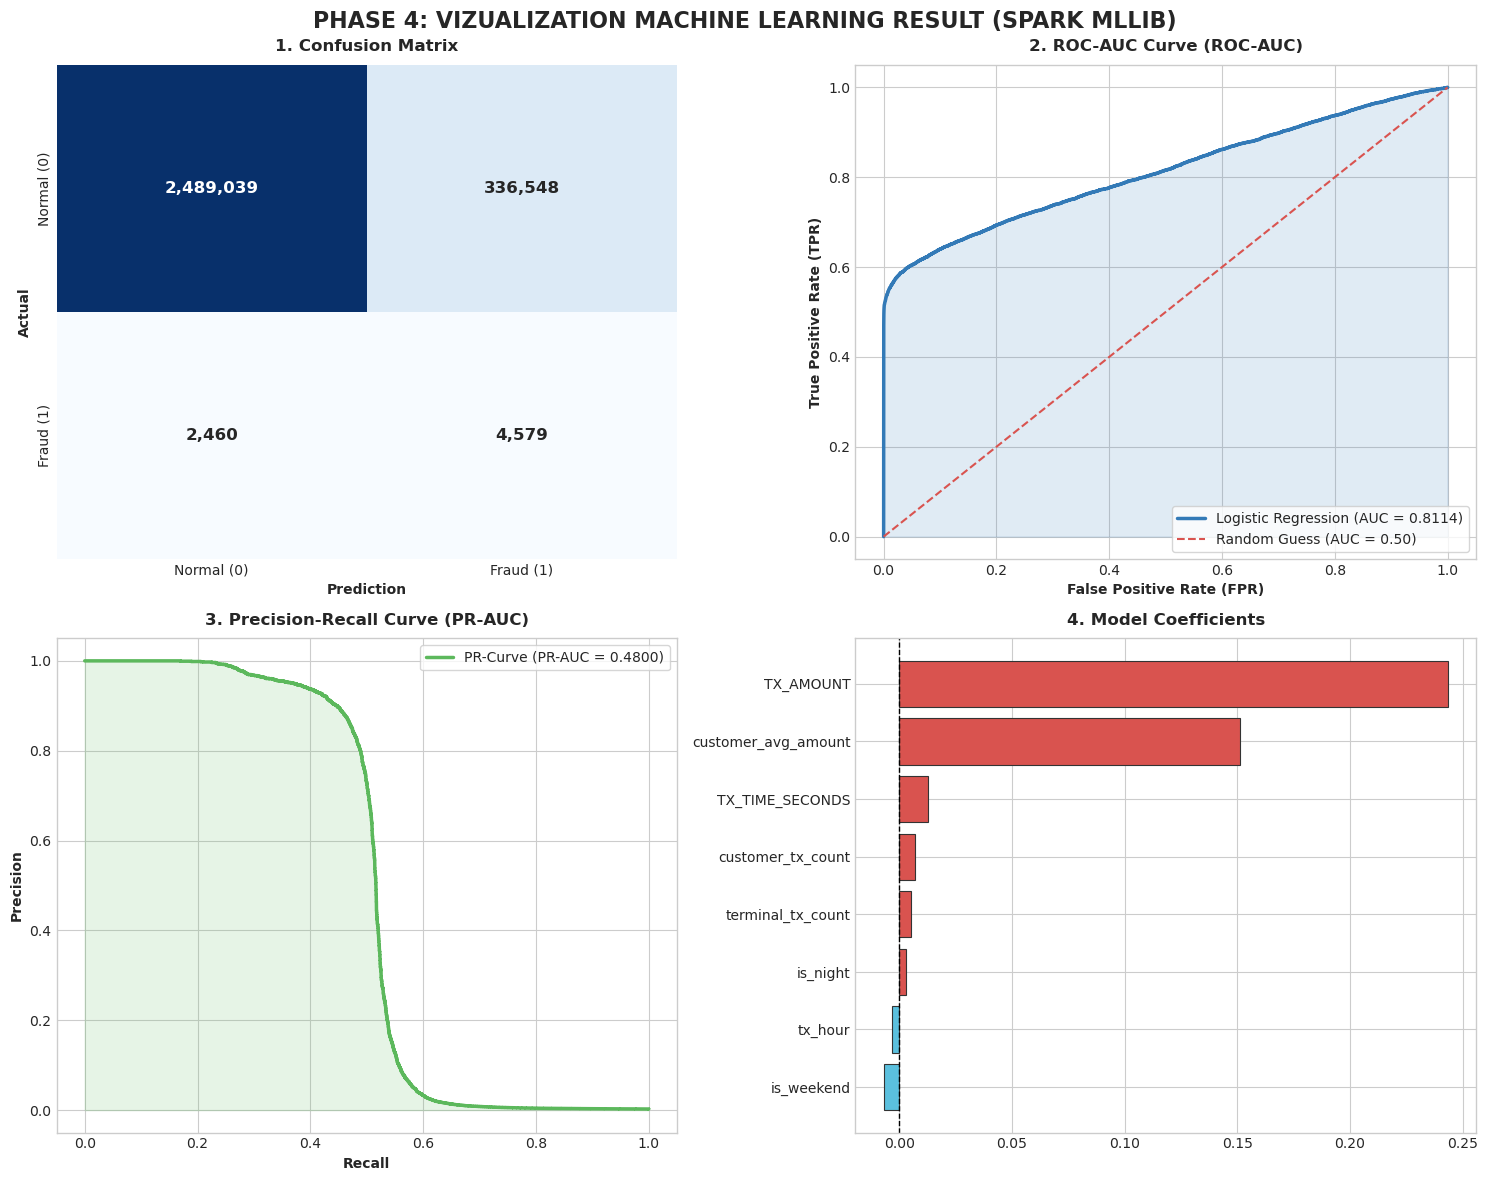

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve

# Thiết lập style đồ họa
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Lấy nhãn thực tế và xác suất dự đoán từ PySpark DataFrame sang Pandas/Numpy
pdf_preds = predictions.select(LABEL_COL, "prediction", "probability").toPandas()

y_true = pdf_preds[LABEL_COL].values
y_pred = pdf_preds["prediction"].values
# Cột xác suất của nhãn 1 (Gian lận)
y_prob = np.array([p[1] for p in pdf_preds["probability"].values])

# Khởi tạo khung hình chứa 4 biểu đồ
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle("PHASE 4: VIZUALIZATION MACHINE LEARNING RESULT (SPARK MLLIB)", fontsize=16, fontweight='bold', y=0.98)

# ----------------------------------------------------
# Biểu đồ 1: Confusion Matrix Heatmap
# ----------------------------------------------------
cm = confusion_matrix(y_true, y_pred)
cm_labels = ['Normal (0)', 'Fraud (1)']
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[0, 0],
            xticklabels=cm_labels, yticklabels=cm_labels, cbar=False, annot_kws={"size": 12, "weight": "bold"})
axes[0, 0].set_title('1. Confusion Matrix', fontsize=12, fontweight='bold', pad=10)
axes[0, 0].set_xlabel('Prediction', fontsize=10, fontweight='bold')
axes[0, 0].set_ylabel('Actual', fontsize=10, fontweight='bold')

# ----------------------------------------------------
# Biểu đồ 2: ROC Curve (Receiver Operating Characteristic)
# ----------------------------------------------------
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = metrics_check['areaUnderROC']

axes[0, 1].plot(fpr, tpr, color='#337ab7', lw=2.5, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='#d9534f', linestyle='--', lw=1.5, label='Random Guess (AUC = 0.50)')
axes[0, 1].fill_between(fpr, tpr, alpha=0.15, color='#337ab7')
axes[0, 1].set_title('2. ROC-AUC Curve (ROC-AUC)', fontsize=12, fontweight='bold', pad=10)
axes[0, 1].set_xlabel('False Positive Rate (FPR)', fontsize=10, fontweight='bold')
axes[0, 1].set_ylabel('True Positive Rate (TPR)', fontsize=10, fontweight='bold')
axes[0, 1].legend(loc='lower right', frameon=True)

# ----------------------------------------------------
# Biểu đồ 3: Precision-Recall Curve
# ----------------------------------------------------
precision, recall, _ = precision_recall_curve(y_true, y_prob)
pr_auc = metrics_check['areaUnderPR']

axes[1, 0].plot(recall, precision, color='#5cb85c', lw=2.5, label=f'PR-Curve (PR-AUC = {pr_auc:.4f})')
axes[1, 0].fill_between(recall, precision, alpha=0.15, color='#5cb85c')
axes[1, 0].set_title('3. Precision-Recall Curve (PR-AUC)', fontsize=12, fontweight='bold', pad=10)
axes[1, 0].set_xlabel('Recall', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Precision', fontsize=10, fontweight='bold')
axes[1, 0].legend(loc='upper right', frameon=True)

# ----------------------------------------------------
# Biểu đồ 4: Feature Importance (Logistic Regression Coefficients)
# ----------------------------------------------------
lr_model = model.stages[-1] # Lấy stage LogisticRegression trong Pipeline
coefficients = lr_model.coefficients.toArray()

df_coef = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=True)

colors = ['#d9534f' if c > 0 else '#5bc0de' for c in df_coef['Coefficient']]
bars = axes[1, 1].barh(df_coef['Feature'], df_coef['Coefficient'], color=colors, edgecolor='#333333', linewidth=0.8)
axes[1, 1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_title('4. Model Coefficients', fontsize=12, fontweight='bold', pad=10)


plt.tight_layout()
plt.show()


## 8. Kết luận Phase 4
- Đã hoàn thành pipeline Spark MLlib: **Hive → VectorAssembler (+ StandardScaler) → Class Weighting → Logistic Regression → PR-AUC / ROC-AUC**.
- Module tái sử dụng: `src/ml_module.py`.
- Chạy lại full production path:
  1. `docker compose -f docker/docker-compose.yml up -d`
  2. ETL full data: `docker exec jupyter-lab spark-submit --driver-memory 4g /home/jovyan/src/etl_module_credit_transaction.py data/simulated-data-raw-csv`
  3. Run All notebook này (hoặc `spark-submit .../src/ml_module.py`).